<a href="https://colab.research.google.com/github/chiquixs/jobsheet/blob/main/data-mining/jobsheet4/titanic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Mounted at /content/drive
MENCARI DATA NULL
Kolom data Train dengan nilai NULL :
 PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64
----------
Kolom data Test dengan nilai NULL :
 PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64
----------
 
 
 
MENGISI MISSING VALUE
Survived    0
Pclass      0
Name        0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64
----------
PassengerId      0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          327
Embarked         0
dtype: in

/tmp/ipykernel_721/2920110951.py:99: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(data1[[x, Target[0]]].groupby(x, as_index=False).mean())
/tmp/ipykernel_721/2920110951.py:99: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(data1[[x, Target[0]]].groupby(x, as_index=False).mean())


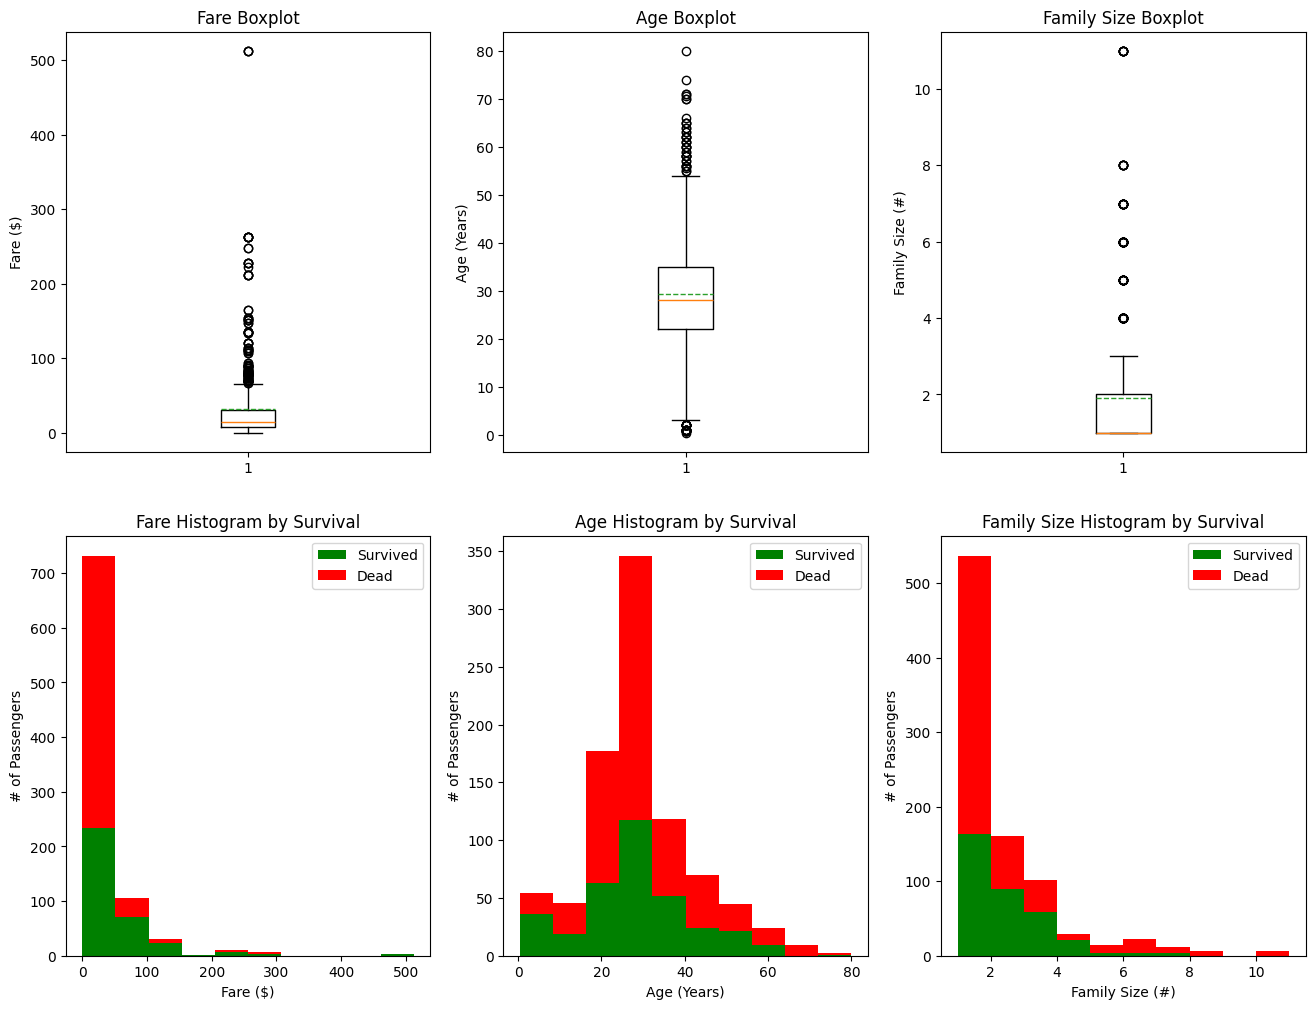

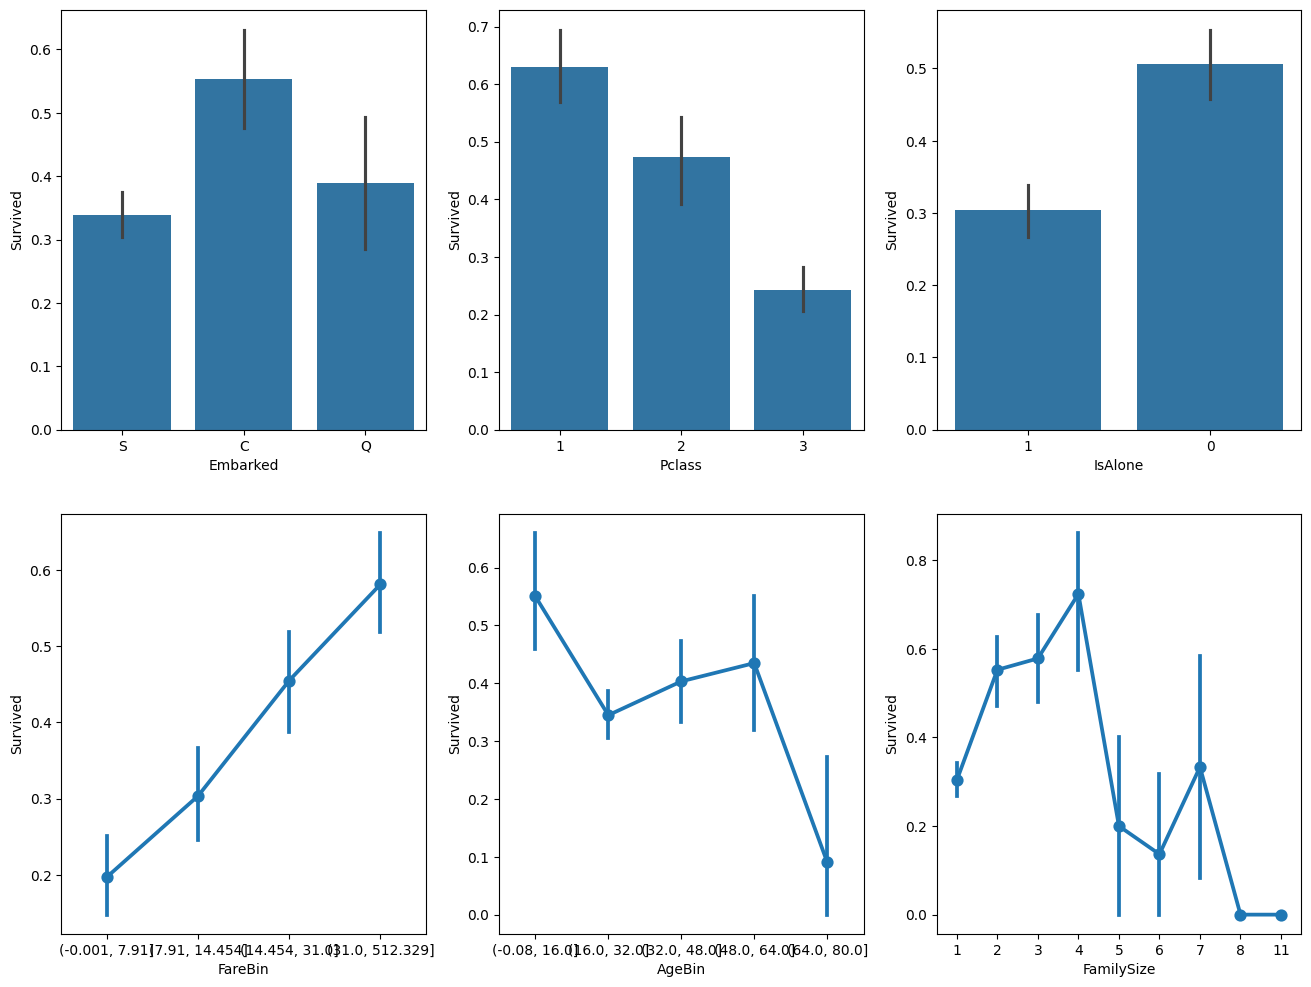

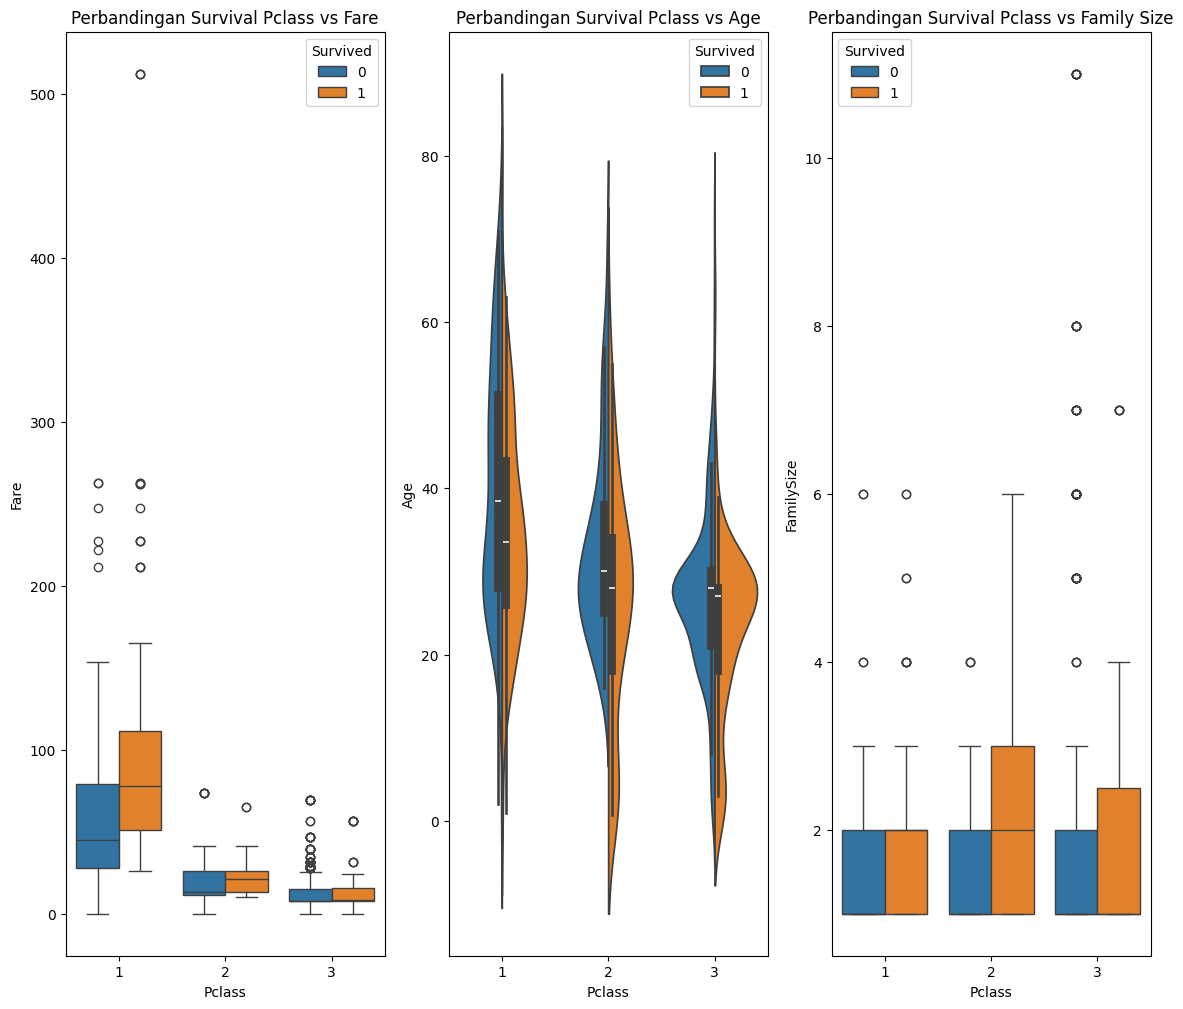

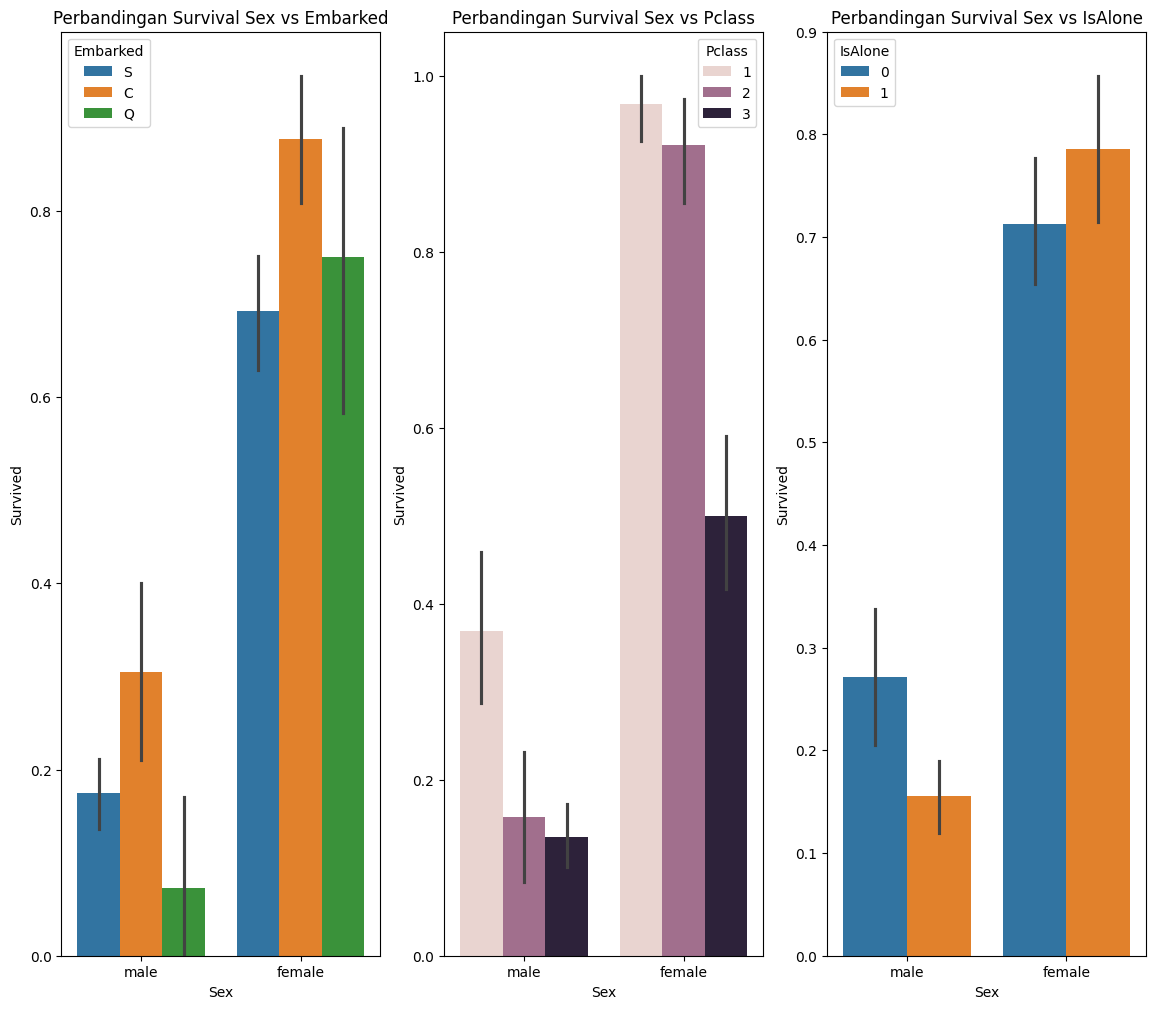

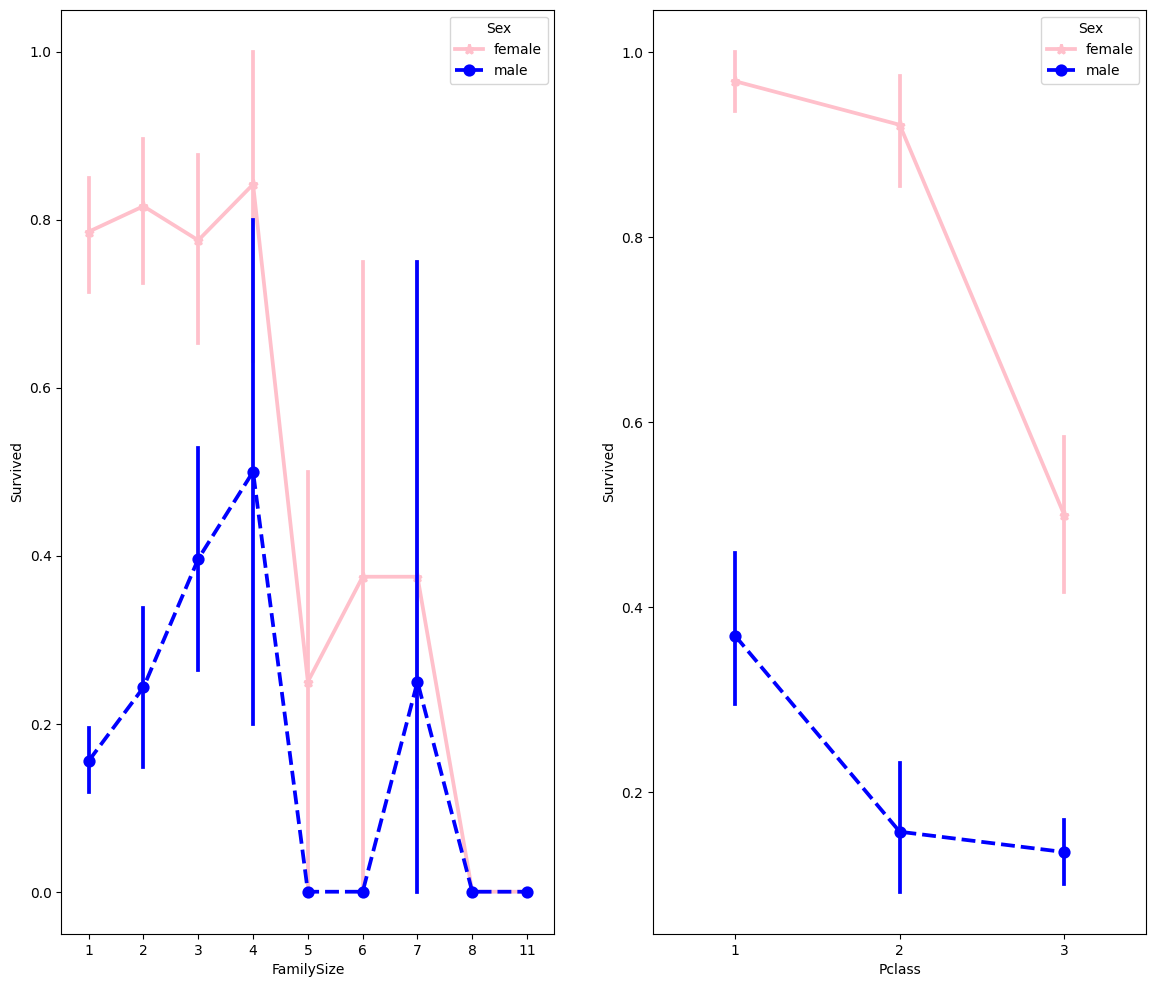

/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:718: UserWarning: Using the pointplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:723: UserWarning: Using the pointplot function without specifying `hue_order` is likely to produce an incorrect plot.
  warnings.warn(warning)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95.0)` for the same effect.

  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95.0)` for the same effect.

  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95.0)` for the same effect.

  func(*plot_args, **plot_kwargs

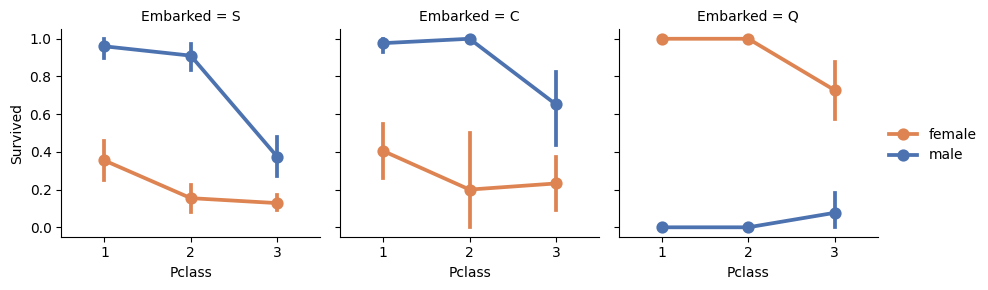

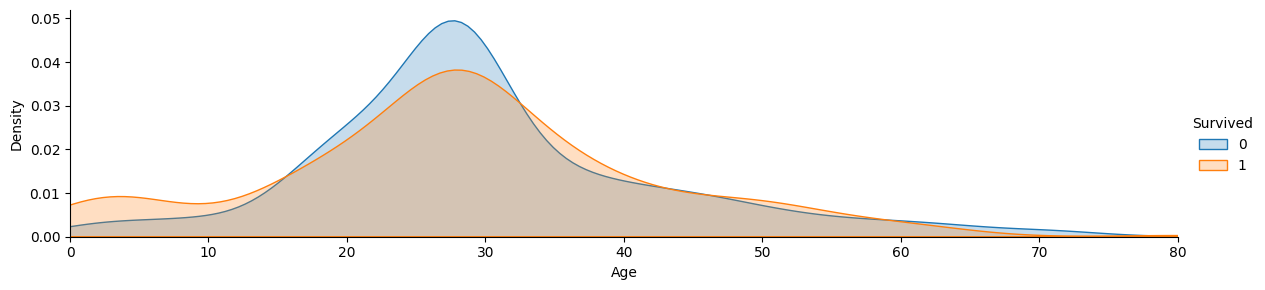

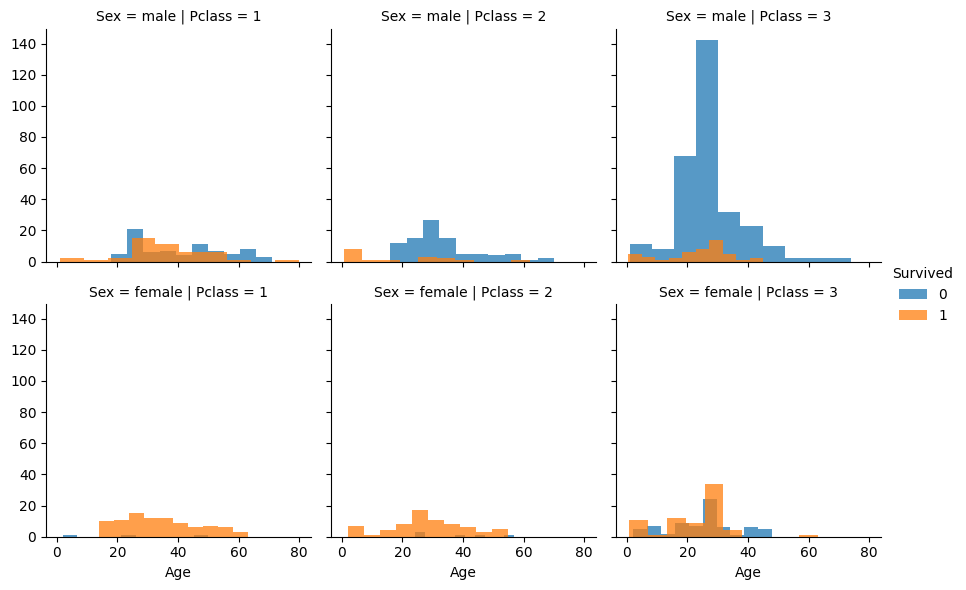

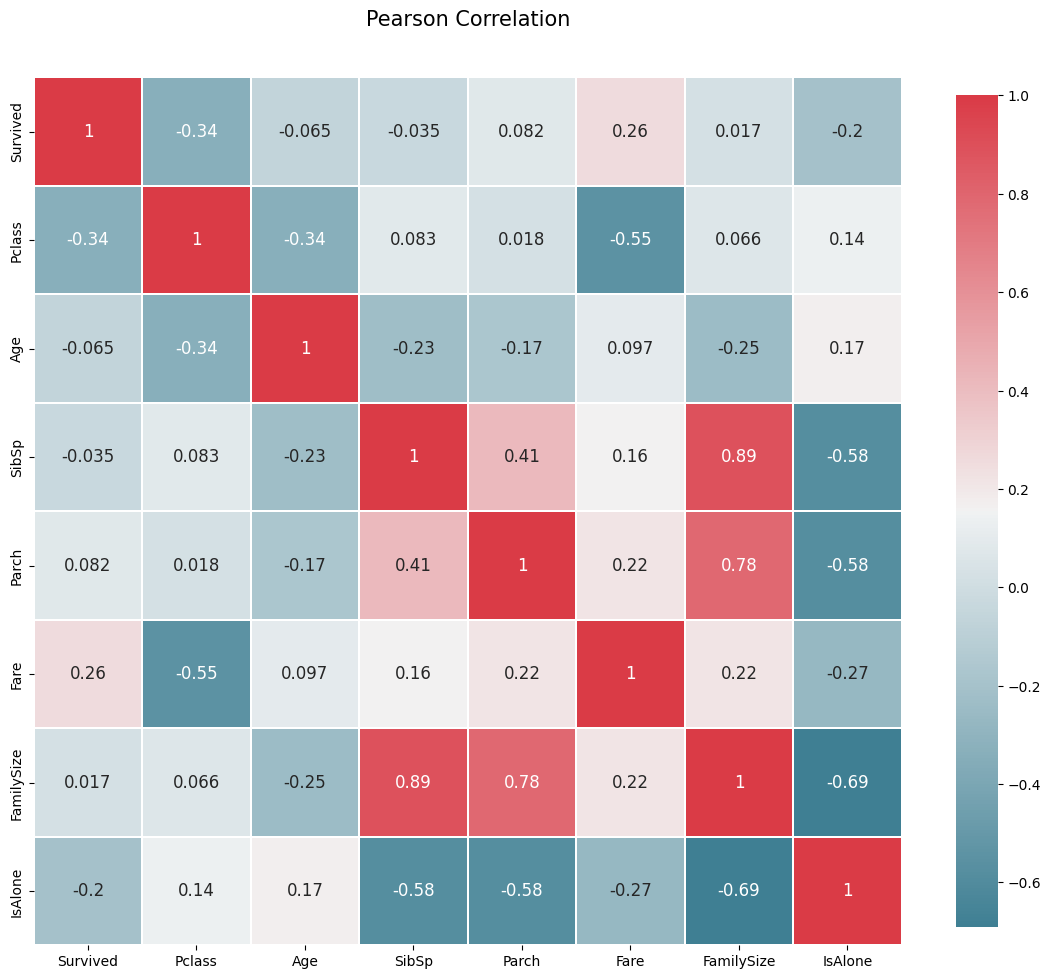

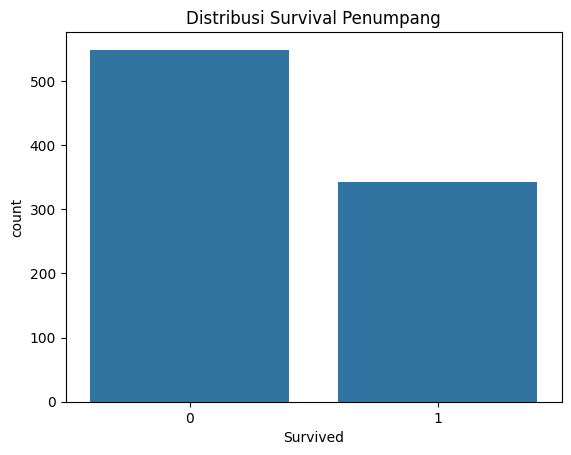

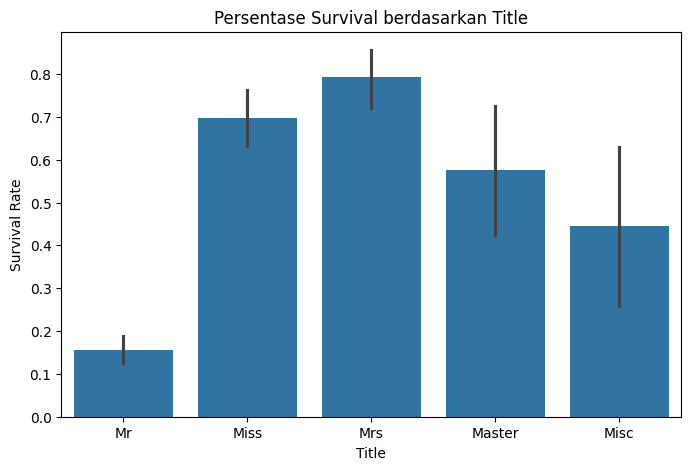

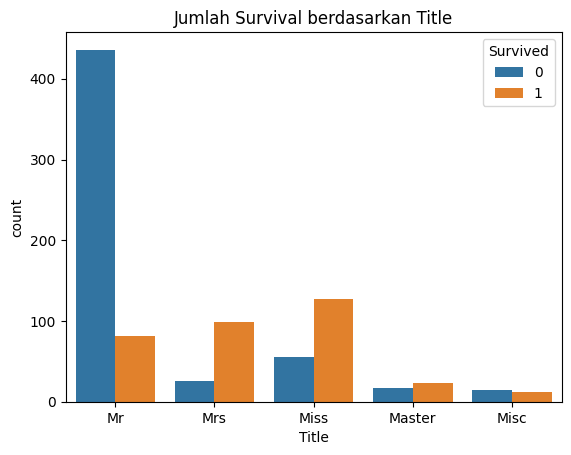

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn import model_selection

from google.colab import drive
drive.mount('/content/drive')

data_raw = pd.read_csv('/content/drive/MyDrive/DATASET/train.csv')
data_val = pd.read_csv('/content/drive/MyDrive/DATASET/test.csv')


# 1. Looking for NULL Data
data1 = data_raw.copy(deep = True)
data_cleaner = [data1, data_val]

print('MENCARI DATA NULL')
print('Kolom data Train dengan nilai NULL :\n', data1.isnull().sum())
print("-"*10)

print('Kolom data Test dengan nilai NULL :\n', data_val.isnull().sum())
print("-"*10)
print(" ")
print(" ")
print(" ")
data_raw.describe(include = 'all')

# 2. isi missing value dan hapus kolom yg tidak diperlukan
for dataset in data_cleaner:
  dataset['Age'] = dataset['Age'].fillna(dataset['Age'].median())
  dataset['Embarked'] = dataset['Embarked'].fillna(dataset['Embarked'].mode()[0])
  dataset['Fare'] = dataset['Fare'].fillna(dataset['Fare'].median())

  # #isikan age yang kosong dengan median
  # dataset['Age'].fillna(dataset['Age'].median(), inplace=True)

  # #isikan embarked dengan modus
  # dataset['Embarked'].fillna(dataset['Embarked'].mode()[0], inplace=True)

  # #isikan fare dengan median
  # dataset['Fare'].fillna(dataset['Fare'].median(), inplace=True)

#hapus atribut cabin dan lainnya yang kita anggap tidak diperlukan
drop_column = ['PassengerId', 'Cabin', 'Ticket']
data1.drop(drop_column, axis=1, inplace=True)
print('MENGISI MISSING VALUE')
print(data1.isnull().sum())
print("-"*10)
print(data_val.isnull().sum())
print(" ")
print(" ")
print(" ")

# 3. membuat kolom baru / atribut baru
for dataset in data_cleaner:
  # variable discrete
  dataset['FamilySize'] = dataset ['SibSp'] + dataset['Parch'] + 1

  dataset['IsAlone'] = 1 # diisikan 1 jika sendiri
  dataset.loc[dataset['FamilySize'] > 1, 'IsAlone'] = 0 # isikan 0 jika ada relasi yg bersama

  # Pisahkan title dari nama
  dataset['Title'] = dataset['Name'].str.split(", ", expand=True)[1].str.split(".", expand=True)[0]

  # Buat bin Fare menggunakan qcut atau bin Frekuensi
  dataset['FareBin'] = pd.qcut(dataset['Fare'], 4)

  # buat bin age menggunakan cut or nilai bin
  dataset['AgeBin'] = pd.cut(dataset['Age'].astype(int), 5)

# Bersihkan title yang jarang ada
stat_min = 10
title_names = (data1['Title'].value_counts() < stat_min)

print('Membuat atribut baru dan menghitung title')
data1['Title'] = data1['Title'].apply(lambda x: 'Misc' if title_names.loc[x] == True else x)
print(data1['Title'].value_counts())
print("-"*10)

# Tampilkan data lagi
data1.info()
data_val.info()
data1.sample(10)
print(" ")
print(" ")
print(" ")

# 4. melakukan Analisa Exploratory
#Discrete Variable Correlation dengan Survival menggunakan
#group by / pivot table: https://pandas.pydata.org/pandas-docs/stable/generated/pandas.DataFrame.groupby.html
Target = ['Survived']

for x in data1.columns:
    if data1[x].dtype != 'float64' and x != 'Survived':
        print('Korelasi Survival dengan:', x)
        print(data1[[x, Target[0]]].groupby(x, as_index=False).mean())
        print('-'*10, '\n')

#menggunakan crosstabs
print(pd.crosstab(data1['Title'], data1[Target[0]]))

import matplotlib.pyplot as plt


# 5. grafis dalam berbagai bentuk
# Inisialisasi figure dengan ukuran 16x12
plt.figure(figsize=[16, 12])

# --- Subplot 1: Fare Boxplot ---
plt.subplot(231)
plt.boxplot(x=data1['Fare'], showmeans=True, meanline=True)
plt.title('Fare Boxplot')
plt.ylabel('Fare ($)')

# --- Subplot 2: Age Boxplot ---
plt.subplot(232)
plt.boxplot(data1['Age'], showmeans=True, meanline=True)
plt.title('Age Boxplot')
plt.ylabel('Age (Years)')

# --- Subplot 3: Family Size Boxplot ---
plt.subplot(233)
plt.boxplot(data1['FamilySize'], showmeans=True, meanline=True)
plt.title('Family Size Boxplot')
plt.ylabel('Family Size (#)')

# --- Subplot 4: Fare Histogram by Survival ---
plt.subplot(234)
plt.hist(x=[data1[data1['Survived']==1]['Fare'], data1[data1['Survived']==0]['Fare']],
         stacked=True, color=['g', 'r'], label=['Survived', 'Dead'])
plt.title('Fare Histogram by Survival')
plt.xlabel('Fare ($)')
plt.ylabel('# of Passengers')
plt.legend()

# --- Subplot 5: Age Histogram by Survival ---
plt.subplot(235)
plt.hist(x=[data1[data1['Survived']==1]['Age'], data1[data1['Survived']==0]['Age']],
         stacked=True, color=['g', 'r'], label=['Survived', 'Dead'])
plt.title('Age Histogram by Survival')
plt.xlabel('Age (Years)')
plt.ylabel('# of Passengers')
plt.legend()

# --- Subplot 6: Family Size Histogram by Survival ---
plt.subplot(236)
plt.hist(x=[data1[data1['Survived']==1]['FamilySize'], data1[data1['Survived']==0]['FamilySize']],
         stacked=True, color=['g', 'r'], label=['Survived', 'Dead'])
plt.title('Family Size Histogram by Survival')
plt.xlabel('Family Size (#)')
plt.ylabel('# of Passengers')
plt.legend()

plt.show()


# 6. menggunakan seaborn
# kita gunakan seaborn untuk perbandingan antar variabel: https://seaborn.pydata.org/api.html
# graph individual features dengan survival
fig, saxis = plt.subplots(2, 3, figsize=(16,12))

sns.barplot(x = 'Embarked', y = 'Survived', data=data1, ax = saxis[0,0])
sns.barplot(x = 'Pclass', y = 'Survived', order=[1,2,3], data=data1, ax = saxis[0,1])
sns.barplot(x = 'IsAlone', y = 'Survived', order=[1,0], data=data1, ax = saxis[0,2])

sns.pointplot(x = 'FareBin', y = 'Survived',  data=data1, ax = saxis[1,0])
sns.pointplot(x = 'AgeBin', y = 'Survived',  data=data1, ax = saxis[1,1])
sns.pointplot(x = 'FamilySize', y = 'Survived', data=data1, ax = saxis[1,2])

plt.show()

# 7. perbandingan dalam boxplot dan violinplot dengan seaborn
# grafik distribusi dari data kualitatif: Pclass
# Pclass cukup tinggi korelasinya dengan survival, berikut akan ditunjukkan perbandingan Pclass dengan bbrp fitur lain
fig, (axis1, axis2, axis3) = plt.subplots(1, 3, figsize=(14, 12))

sns.boxplot(x='Pclass', y='Fare', hue='Survived', data=data1, ax=axis1)
axis1.set_title('Perbandingan Survival Pclass vs Fare')

sns.violinplot(x='Pclass', y='Age', hue='Survived', data=data1, split=True, ax=axis2)
axis2.set_title('Perbandingan Survival Pclass vs Age')

sns.boxplot(x='Pclass', y='FamilySize', hue='Survived', data=data1, ax=axis3)
axis3.set_title('Perbandingan Survival Pclass vs Family Size')

plt.show()


# 8. hasil perbandingan dalam barplot
# Grafik Distribusi Data Kualitatif: Sex
# Sex cukup tinggi korelasinya dengan survival, berikut perbandingannya dengan fitur lain
fig, qaxis = plt.subplots(1, 3, figsize=(14, 12))

sns.barplot(x='Sex', y='Survived', hue='Embarked', data=data1, ax=qaxis[0])
qaxis[0].set_title('Perbandingan Survival Sex vs Embarked')

sns.barplot(x='Sex', y='Survived', hue='Pclass', data=data1, ax=qaxis[1])
qaxis[1].set_title('Perbandingan Survival Sex vs Pclass')

sns.barplot(x='Sex', y='Survived', hue='IsAlone', data=data1, ax=qaxis[2])
qaxis[2].set_title('Perbandingan Survival Sex vs IsAlone')

plt.show()


# 9.hasil perbandingan dalam pointplot
# Bagaimana pengaruh ukuran keluarga dan kelas terhadap jenis kelamin dan survival
fig, (maxis1, maxis2) = plt.subplots(1, 2, figsize=(14, 12))

sns.pointplot(x="FamilySize", y="Survived", hue="Sex", data=data1,
              palette={"male": "blue", "female": "pink"},
              markers=["*", "o"], linestyles=["-", "--"], ax=maxis1)

sns.pointplot(x="Pclass", y="Survived", hue="Sex", data=data1,
              palette={"male": "blue", "female": "pink"},
              markers=["*", "o"], linestyles=["-", "--"], ax=maxis2)

plt.show()

# 10. hasil perbandingan dalam pointplot
#bagaimana pengaruh faktor port keberangkatan terhadap perbandingan Pclass, sex, dan survival
#facetgrid: https://seaborn.pydata.org/generated/seaborn.FacetGrid.html
e = sns. FacetGrid(data1, col = 'Embarked' )
e.map(sns.pointplot, 'Pclass', 'Survived', 'Sex' , ci=95.0, palette = 'deep' )
e.add_legend()

#11. hasil perbandingan dalam kdeplot
#plot distribusi dari usia penumpang yang selamat / tidak selamat
a = sns. FacetGrid( data1, hue = 'Survived', aspect=4 )
a.map(sns.kdeplot, 'Age', shade= True )
a.set(xlim=(0 , data1['Age'].max()))
a.add_legend()

#12.  hasil perbandingan dalam histogram
#perbandingan histogram dari sex, class, dan age dengan survival
h = sns. FacetGrid(data1, row = 'Sex', col = 'Pclass', hue = 'Survived' )
h.map(plt.hist, 'Age', alpha = .75)
h.add_legend ()

# 13. Korelasi Heatmap
def correlation_heatmap(df):
    _, ax = plt.subplots(figsize=(14, 12))
    colormap = sns.diverging_palette(220, 10, as_cmap=True)

    # Hanya dipilih fitur numerik saja
    numerical_df = df.select_dtypes(include=['number'])

    _ = sns.heatmap(
        numerical_df.corr(),
        cmap=colormap,
        square=True,
        cbar_kws={'shrink': .9},
        ax=ax,
        annot=True,
        linewidths=0.1, vmax=1.0, linecolor='white',
        annot_kws={'fontsize': 12}
    )

    plt.title('Pearson Correlation', y=1.05, size=15)

correlation_heatmap(data1)

plt.show()

# 12. Tambahan grafik deskriptif
# Countplot Survival untuk melihat jumlah yang selamat dan tidak
sns.countplot(x='Survived', data=data1)
plt.title('Distribusi Survival Penumpang')
plt.show()

# Barplot untuk menunjukkan Presentase survival berdasarkan title dari kolom baru yang sudah dibuat
plt.figure(figsize=(8,5))

sns.barplot(x='Title', y='Survived', data=data1, order=['Mr','Miss','Mrs','Master','Misc'])

plt.title('Persentase Survival berdasarkan Title')
plt.xlabel('Title')
plt.ylabel('Survival Rate')

plt.show()

# Countplot untuk jumlah yang selamat vs tidak selamat per Title
sns.countplot(x='Title', hue='Survived', data=data1)
plt.title('Jumlah Survival berdasarkan Title')
plt.show()